<a href="https://colab.research.google.com/github/Tejaswimadastu/Deep_Learning/blob/main/Spam_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TASK 1**

Objective

Understand dataset patterns.

**Tasks**

Check dataset shape

Count spam vs ham

Find average message length

Plot word frequency


In [1]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

In [4]:
import pandas as pd

df = pd.read_csv("spam.csv", encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
print("Shape:", df.shape)

Shape: (5572, 2)


In [7]:
print(df['label'].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


In [8]:
df['length'] = df['message'].apply(len)
print("Average Length:", df['length'].mean())

Average Length: 80.11880832735105


In [9]:
all_words = []

for msg in df['message']:
    words = re.findall(r'\w+', msg.lower())
    all_words.extend(words)

word_freq = Counter(all_words)
common_words = word_freq.most_common(10)

print(common_words)

[('i', 3001), ('to', 2242), ('you', 2240), ('a', 1433), ('the', 1328), ('u', 1192), ('and', 979), ('in', 898), ('is', 890), ('me', 802)]


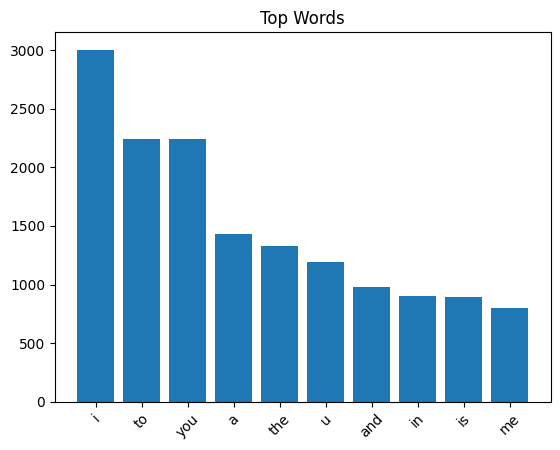

In [11]:
words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top Words")
plt.show()

# **TASK 2 — Text Preprocessing Pipeline**

Build a reusable function that performs:

1. Lowercasing
2. Tokenization
3. Stopword removal
4. Punctuation removal
5. Lemmatization

**Bonus**

Create a single pipeline function
def preprocess(text):
    ...
    return cleaned_text

In [12]:
!pip install nltk

import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download resources (run once)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

# Pipeline Creation

In [19]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [20]:
def preprocess(text):
  #lowercase
  text=text.lower()
  #remove punctuations
  text=re.sub(r'[^\w\s]','',text)
  #Tokenization
  tokens = nltk.word_tokenize(text)
  #Stopword removal
  tokens = [word for word in tokens if word not in stop_words]
  #Lemmatization
  tokens = [lemmatizer.lemmatize(word) for word in tokens]
  cleaned_text = " ".join(tokens)

  return cleaned_text


In [21]:
sample="Hii!!! This is, M.Tejaswi & Iam from cse-g"
print(preprocess(sample))

hii mtejaswi iam cseg


In [22]:
df['cleaned'] = df['message'].apply(preprocess)
df.head()

,label,message,length,cleaned
0,ham,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,29,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry 2 wkly comp win fa cup final tkts 2...
3,ham,U dun say so early hor... U c already then say...,49,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,nah dont think go usf life around though


# **TASK 3 — Feature Engineering (BoW vs TF-IDF)**

**Tasks**

Convert text using:

1. CountVectorizer (BoW)
2. TfidfVectorizer

Compare:

1. Feature size
2. Sparsity
3. Model performance


In [23]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

In [24]:
X = df['cleaned']   # from Task 2
y = df['label']

# Convert labels to 0/1
y = y.map({'ham': 0, 'spam': 1})

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
bow = CountVectorizer()
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

print("BoW Feature Size:", X_train_bow.shape)

BoW Feature Size: (4457, 7832)


In [26]:
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF Feature Size:", X_train_tfidf.shape)

TF-IDF Feature Size: (4457, 7832)


In [27]:
def sparsity(matrix):
    return 1.0 - (matrix.count_nonzero() / (matrix.shape[0] * matrix.shape[1]))

print("BoW Sparsity:", sparsity(X_train_bow))
print("TF-IDF Sparsity:", sparsity(X_train_tfidf))

BoW Sparsity: 0.9989191635519341
TF-IDF Sparsity: 0.9989191635519341


In [28]:
model_bow = LogisticRegression()
model_bow.fit(X_train_bow, y_train)

pred_bow = model_bow.predict(X_test_bow)
print("BoW Accuracy:", accuracy_score(y_test, pred_bow))

BoW Accuracy: 0.9766816143497757


In [29]:
model_tfidf = LogisticRegression()
model_tfidf.fit(X_train_tfidf, y_train)

pred_tfidf = model_tfidf.predict(X_test_tfidf)
print("TF-IDF Accuracy:", accuracy_score(y_test, pred_tfidf))

TF-IDF Accuracy: 0.9506726457399103


# **TASK 4 — Baseline Model**

Build a simple model:

**Algorithm:** Logistic Regression

Steps

1. Train model
2. Evaluate accuracy
3. Confusion matrix

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [31]:
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

LogisticRegression()

In [32]:
y_pred = model.predict(X_test_tfidf)

In [33]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9506726457399103


In [34]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[961   4]
 [ 51  99]]


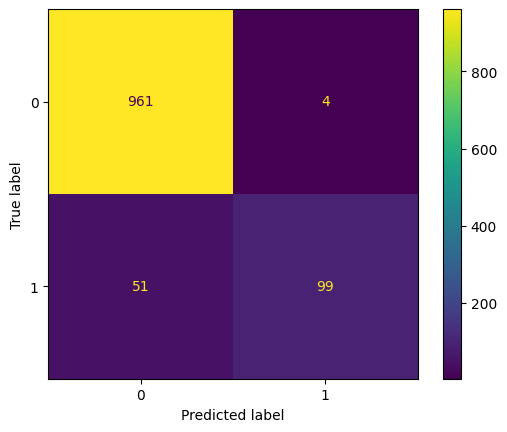

In [35]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# **TASK 5 — Model Comparison**
Train multiple models:

1. Naive Bayes
2. Logistic Regression
3. SVM

**Compare:**

1. Accuracy
2. Precision
3. Recall
4. F1-score


In [36]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

In [37]:
# Models
nb = MultinomialNB()
lr = LogisticRegression()
svm = SVC()

# Train
nb.fit(X_train_tfidf, y_train)
lr.fit(X_train_tfidf, y_train)
svm.fit(X_train_tfidf, y_train)

SVC()

In [38]:
pred_nb = nb.predict(X_test_tfidf)
pred_lr = lr.predict(X_test_tfidf)
pred_svm = svm.predict(X_test_tfidf)

In [39]:
def evaluate(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    ]

In [40]:
results = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression", "SVM"],
    "Accuracy": [
        evaluate(y_test, pred_nb)[0],
        evaluate(y_test, pred_lr)[0],
        evaluate(y_test, pred_svm)[0]
    ],
    "Precision": [
        evaluate(y_test, pred_nb)[1],
        evaluate(y_test, pred_lr)[1],
        evaluate(y_test, pred_svm)[1]
    ],
    "Recall": [
        evaluate(y_test, pred_nb)[2],
        evaluate(y_test, pred_lr)[2],
        evaluate(y_test, pred_svm)[2]
    ],
    "F1-score": [
        evaluate(y_test, pred_nb)[3],
        evaluate(y_test, pred_lr)[3],
        evaluate(y_test, pred_svm)[3]
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1-score
0          Naive Bayes  0.964126   1.000000  0.733333  0.846154
1  Logistic Regression  0.950673   0.961165  0.660000  0.782609
2                  SVM  0.974888   0.984127  0.826667  0.898551


# **TASK 6 — Hyperparameter Tuning (GridSearchCV)**

In [41]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Logistic Regression tuning
param_lr = {'C': [0.01, 0.1, 1, 10]}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_lr, cv=5)
grid_lr.fit(X_train_tfidf, y_train)

print("Best LR C:", grid_lr.best_params_)
print("Best LR Score:", grid_lr.best_score_)

Best LR C: {'C': 10}
Best LR Score: 0.9732985057349779


In [42]:
# SVM tuning
param_svm = {'kernel': ['linear', 'rbf']}
grid_svm = GridSearchCV(SVC(), param_svm, cv=5)
grid_svm.fit(X_train_tfidf, y_train)

print("Best SVM:", grid_svm.best_params_)
print("Best SVM Score:", grid_svm.best_score_)

Best SVM: {'kernel': 'linear'}
Best SVM Score: 0.9766632443015105


# **TASK 7 — N-grams Feature Engineering**

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Bigram
tfidf_2 = TfidfVectorizer(ngram_range=(1,2))
X_train_2 = tfidf_2.fit_transform(X_train)
X_test_2 = tfidf_2.transform(X_test)

# Trigram
tfidf_3 = TfidfVectorizer(ngram_range=(1,3))
X_train_3 = tfidf_3.fit_transform(X_train)
X_test_3 = tfidf_3.transform(X_test)

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)

model.fit(X_train_2, y_train)
print("Bigram Accuracy:", accuracy_score(y_test, model.predict(X_test_2)))

model.fit(X_train_3, y_train)
print("Trigram Accuracy:", accuracy_score(y_test, model.predict(X_test_3)))

Bigram Accuracy: 0.9443946188340807
Trigram Accuracy: 0.9381165919282511


# **TASK 8 — Word2Vec + Classifier**

In [45]:
!pip install gensim
from gensim.models import Word2Vec
import numpy as np

sentences = [msg.split() for msg in X_train]

w2v = Word2Vec(sentences, vector_size=50, window=3, min_count=1)

def avg_vector(sentence):
    words = sentence.split()
    vecs = [w2v.wv[w] for w in words if w in w2v.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(50)

X_train_vec = np.array([avg_vector(s) for s in X_train])
X_test_vec = np.array([avg_vector(s) for s in X_test])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 22.5 MB/s eta 0:00:00


In [46]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

print("Word2Vec Accuracy:", accuracy_score(y_test, model.predict(X_test_vec)))

Word2Vec Accuracy: 0.8654708520179372


# **TASK 9 — Sentiment Feature**

In [47]:
!pip install textblob
from textblob import TextBlob

def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df['sentiment'] = df['cleaned'].apply(get_sentiment)

In [48]:
import numpy as np

X_tfidf_full = tfidf.fit_transform(df['cleaned'])
sentiment = df['sentiment'].values.reshape(-1,1)

# Combine features
X_combined = np.hstack((X_tfidf_full.toarray(), sentiment))

# **TASK 10 — NER (spaCy)**

In [55]:
!pip install spacy
!python -m spacy download en_core_web_sm

import spacy
nlp = spacy.load("en_core_web_sm")

text = "Elon Musk works at Tesla in USA"
doc = nlp(text)

for ent in doc.ents:
    print(ent.text, ent.label_)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 77.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Elon Musk PERSON
Tesla ORG
USA GPE


# **TASK 11 — POS Analysis**

In [57]:
import nltk

nltk.download('averaged_perceptron_tagger_eng')  # ✅ required

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [58]:
import nltk
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt')

from collections import Counter

all_tags = []

for msg in df['cleaned']:
    tokens = nltk.word_tokenize(msg)
    tags = nltk.pos_tag(tokens)
    all_tags.extend(tags)

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [59]:
verbs = [w for w,t in all_tags if t.startswith('VB')]
nouns = [w for w,t in all_tags if t.startswith('NN')]

print("Top Verbs:", Counter(verbs).most_common(5))
print("Top Nouns:", Counter(nouns).most_common(5))

Top Verbs: [('go', 294), ('get', 264), ('got', 248), ('know', 234), ('come', 187)]
Top Nouns: [('call', 448), ('im', 340), ('day', 241), ('time', 232), ('u', 199)]


# **TASK 12 — Bigram Language Model**

In [60]:
from collections import defaultdict

bigram_model = defaultdict(lambda: defaultdict(int))

for sentence in df['cleaned']:
    words = sentence.split()
    for i in range(len(words)-1):
        bigram_model[words[i]][words[i+1]] += 1

In [61]:
def predict_next(word):
    return max(bigram_model[word], key=bigram_model[word].get)

print(predict_next("win"))

å100
